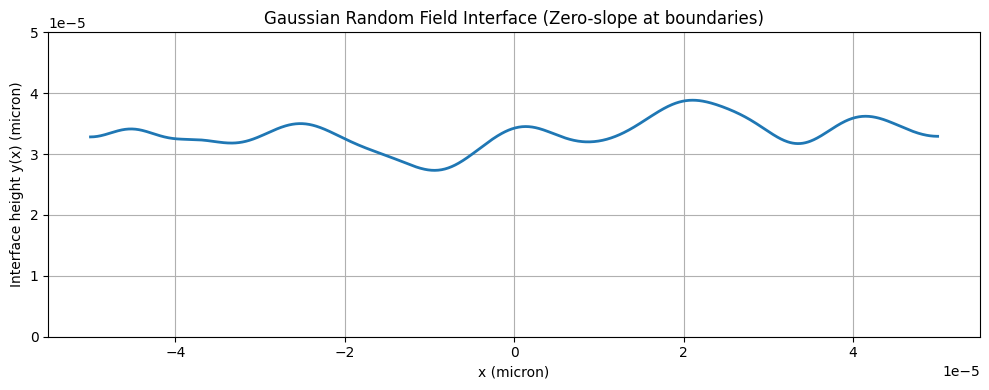

In [23]:
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------
# 1. Gaussian Random Field 随机界面
# ---------------------------
def make_grf_profile_zero_slope(
    xmin, xmax,
    n_modes=80,
    corr_len=5e-6,
    amp_scale=2.0e-6,
    base=None,
    seed=None,
    clip_range=None
):
    rng = np.random.default_rng(seed)
    L = xmax - xmin

    if base is None:
        base = 2.0/3.0 * xmax   # 通常你用 2/3 * L2[1]

    def profile(x):
        x = np.asarray(x, float)
        X = (x - xmin) / L    # normalize

        # GRF 目标： y = base + Σ a_k cos(kπX)
        vals = np.zeros_like(X)

        # 仅余弦项 → 自动零斜率
        for k in range(1, n_modes + 1):
            kappa = (k * np.pi) / L
            power = np.exp(-0.5 * (kappa * corr_len)**2)   # Gaussian spectral density
            sigma_k = amp_scale * np.sqrt(power) / np.sqrt(2)
            a_k = rng.normal(scale=sigma_k)
            vals += a_k * np.cos(k * np.pi * X)

        y = base + vals
        if clip_range is not None:
            y = np.clip(y, clip_range[0], clip_range[1])
        return y

    return profile


# ---------------------------
# 2. 测试界面
# ---------------------------
L1 = [-50e-6, 50e-6]   # x 范围 (和你的代码一致)
L2 = [0, 50e-6]        # y 范围

profile = make_grf_profile_zero_slope(
    xmin=L1[0], 
    xmax=L1[1],
    n_modes=100,
    corr_len=5e-6,
    amp_scale=2.0e-6,
    base=2.0/3.0 * L2[1],
    clip_range=(L2[0], L2[1])
)

# 采样
x = np.linspace(L1[0], L1[1], 1000)
y = profile(x)

# ---------------------------
# 3. 绘图
# ---------------------------
plt.figure(figsize=(10,4))
plt.plot(x, y, linewidth=2)
plt.title("Gaussian Random Field Interface (Zero-slope at boundaries)")
plt.xlabel("x (micron)")
plt.ylabel("Interface height y(x) (micron)")
plt.grid(True)
plt.ylim(L2[0], L2[1])
plt.tight_layout()
plt.show()
